<a href="https://colab.research.google.com/github/ParamAhuja/DL_Notebooks/blob/main/ImageDataGenerator.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# single image

In [1]:
from tensorflow.keras.preprocessing import image
from tensorflow.keras.preprocessing.image import ImageDataGenerator

In [2]:
import requests
from PIL import Image
import io

image_url = "https://github.com/ParamAhuja/DL_Notebooks/blob/main/datasets/kitty-cat-kitten-pet-45201.jpeg?raw=true"

response = requests.get(image_url)
if response.status_code == 200:
    img = Image.open(io.BytesIO(response.content))
    print("Image loaded successfully from URL.")
else:
    print(f"Failed to load image from URL. Status code: {response.status_code}")

Image loaded successfully from URL.


(2500, 2392, 3)


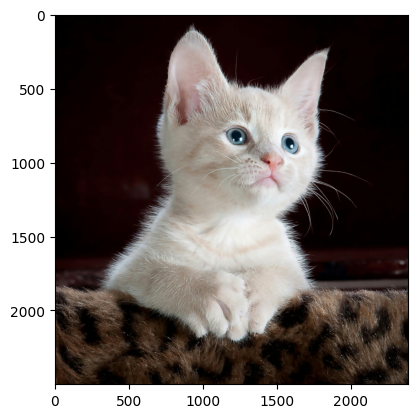

In [3]:
import numpy as np
import cv2
import matplotlib.pyplot as plt
img = (np.array(img)) # pil image to cv2 image
print(img.shape)
plt.imshow(img)

In [4]:
data = ImageDataGenerator(
    rotation_range=40,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    vertical_flip = False,
    # can also use brightness, channel shift, ...
    fill_mode='nearest' # for rotation and zoom out and ..., other modes are "reflect", "constant" ...
)

In [5]:
input_batch = img.reshape((1,2500, 2392, 3))

In [6]:
import os
os.makedirs("augmented", exist_ok = True)

In [7]:
i = 1
for output in data.flow(input_batch, batch_size=32, save_to_dir="augmented"):
  i += 1
  if i > 10:
    break

In [8]:
input_batch.shape

(1, 2500, 2392, 3)

In [9]:
augmented_imgs = []
for augmented in os.listdir("augmented"):
  augmented_img = cv2.imread(os.path.join("/content/augmented", augmented))
  augmented_imgs.append(augmented_img)
augmented_imgs = np.array(augmented_imgs)

In [10]:
augmented_imgs.shape

(10, 2500, 2392, 3)

notes:


1.   original data is discarded, augmented is used
2.   test data is only underwent the formatting changes, not the augmentation steps, altough the generator could be used for the same like in next section



# Full dataset Augmentation and model train

In [11]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Dense, Flatten, BatchNormalization, Dropout
from tensorflow.keras.models import Sequential
from tensorflow.keras.preprocessing.image import ImageDataGenerator

In [69]:
from datasets import load_dataset

dataset_from_hub = load_dataset("ParamDev/ImageClassification")

train_data_from_hub = dataset_from_hub["train"]
test_data_from_hub = dataset_from_hub["test"]

dataset_from_hub

In [13]:
import os
from PIL import Image

# Create directories for saving images if they don't exist
if not os.path.exists("train/dogs"):
    os.makedirs("train/dogs")
if not os.path.exists("train/cats"):
    os.makedirs("train/cats")
if not os.path.exists("test/dogs"):
    os.makedirs("test/dogs")
if not os.path.exists("test/cats"):
    os.makedirs("test/cats")

# Function to save images
def save_images(dataset, split_name):
    for i, example in enumerate(dataset):
        image = example["image"]
        label = example["label"] # 0 for cat, 1 for dog

        # Determine the directory based on the label
        if label == 0:
            label_dir = "cats"
        else:
            label_dir = "dogs"

        # Save the image
        image_path = os.path.join(split_name, label_dir, f"image_{i}.jpg")
        image.save(image_path)

# Save train and test images
save_images(train_data_from_hub, "train")
save_images(test_data_from_hub, "test")

print("Images saved to train/dogs, train/cats, test/dogs, and test/cats directories.")

Images saved to train/dogs, train/cats, test/dogs, and test/cats directories.


In [14]:
# Use Generators for large datasets
train_data = keras.utils.image_dataset_from_directory(
              directory = "/content/train/",
              labels="inferred", # folder names
              label_mode="int",  # encoded
              class_names=None,  # can remove this here
              color_mode="rgb",  # for channels
              batch_size=32,
              image_size=(256, 256),
              shuffle=True,
)
test_data = keras.utils.image_dataset_from_directory(
              directory = "/content/test/",
              labels="inferred",
              label_mode="int",
              class_names=None,
              color_mode="rgb",
              batch_size=32,
              image_size=(256, 256),
              shuffle=True,
)

Found 20000 files belonging to 2 classes.
Found 5000 files belonging to 2 classes.


In [15]:
batch_size = 16

train_data_gen = ImageDataGenerator(
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    # normalize:
    rescale = 1. / 255.
)
test_data_gen = ImageDataGenerator(rescale = 1. / 255.)


train_gen = train_data_gen.flow_from_directory( # use flow_from_directory for a folder of images
    "/content/train",      # dir
    target_size=(150,150), # size of images output
    batch_size = batch_size,
    class_mode = "binary") # for binary labels

test_gen = test_data_gen.flow_from_directory( # use flow_from_directory for a folder of images
    "/content/test",       # dir
    target_size=(150,150), # size of images output
    batch_size = batch_size,
    class_mode = "binary") # for binary labels

Found 20000 images belonging to 2 classes.
Found 5000 images belonging to 2 classes.


In [16]:
model = Sequential()

model.add(Conv2D(filters = 32, kernel_size = (3,3), activation = "relu", padding = "valid", input_shape = (150,150,3)))
model.add(BatchNormalization())
model.add(MaxPooling2D((2,2), strides = 2, padding = "valid"))

model.add(Conv2D(filters = 64, kernel_size = (3,3), activation = "relu", padding = "valid"))
model.add(BatchNormalization())
model.add(MaxPooling2D((2,2), strides = 2, padding = "valid"))

model.add(Conv2D(filters = 128, kernel_size = (3,3), activation = "relu", padding = "valid"))
model.add(BatchNormalization())
model.add(MaxPooling2D((2,2), strides = 2, padding = "valid"))

model.add(Flatten())

model.add(Dense(units = 128, activation = "relu"))
model.add(Dropout(0.1))
model.add(Dense(units = 64, activation = "relu"))
model.add(Dropout(0.1))
model.add(Dense(units = 1, activation = "sigmoid"))

model.summary()

/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 148, 148, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 148, 148, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 74, 74, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 72, 72, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 72, 72, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 36, 36, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 34, 34, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 34, 34, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 17, 17, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 36992)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     4,735,104 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,837,569 (18.45 MB)

 Trainable params: 4,837,121 (18.45 MB)

 Non-trainable params: 448 (1.75 KB)

In [17]:
model.compile(optimizer = "adam", loss = "binary_crossentropy", metrics = ["accuracy"])

history = model.fit(train_gen,
                    steps_per_epoch = 20000 // batch_size, # for controlling how much augmentation should be there, original data is discarded
                    epochs = 5,
                    validation_data = test_gen,
                    validation_steps = 5000 // batch_size, #
                    )


/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/5
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 147s 111ms/step - accuracy: 0.5706 - loss: 1.2351 - val_accuracy: 0.6649 - val_loss: 0.6076
Epoch 2/5
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 190s 106ms/step - accuracy: 0.7203 - loss: 0.5550 - val_accuracy: 0.7003 - val_loss: 0.6294
Epoch 3/5
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 144s 107ms/step - accuracy: 0.7808 - loss: 0.4668 - val_accuracy: 0.7915 - val_loss: 0.4494
Epoch 4/5
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 131s 105ms/step - accuracy: 0.8098 - loss: 0.4116 - val_accuracy: 0.7406 - val_loss: 0.4929
Epoch 5/5
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 142s 105ms/step - accuracy: 0.8364 - loss: 0.3700 - val_accuracy: 0.7083 - val_loss: 0.9882


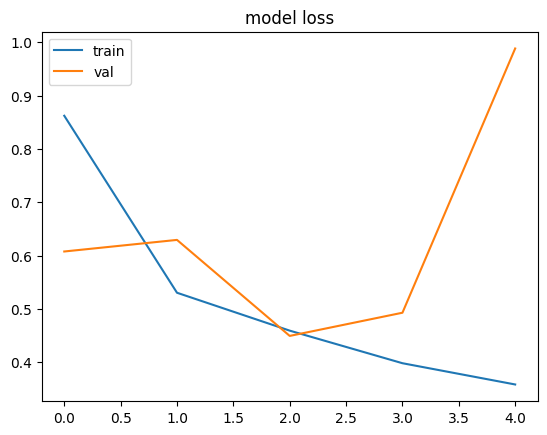

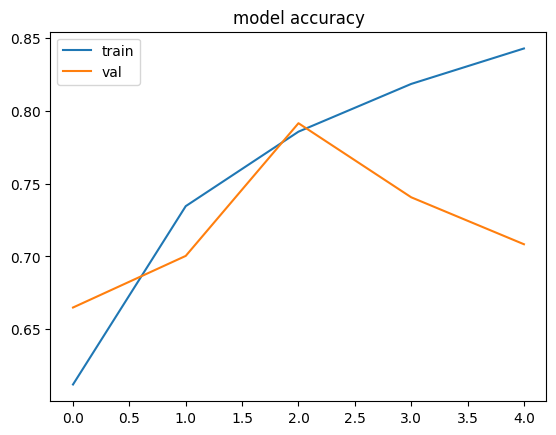

In [18]:
import matplotlib.pyplot as plt

plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('model loss')
plt.legend(['train', 'val'], loc='upper left')
plt.show()

plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('model accuracy')
plt.legend(['train', 'val'], loc='upper left')
plt.show()

# Prediction

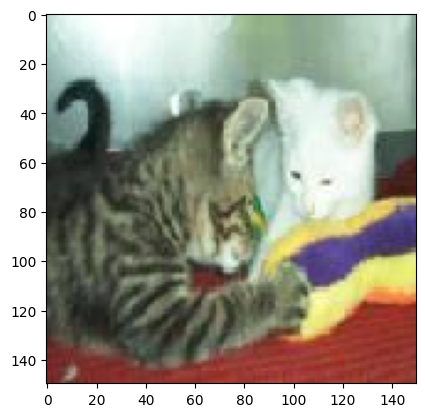

In [67]:
image_batch = test_gen[1]
image = image_batch[0][0]
plt.imshow(image)

In [68]:
y_hat = model.predict(image.reshape((1,150,150,3)))
y_hat

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step


array([[0.00020694]], dtype=float32)